# Modèles

In [6]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Ajout robuste du dossier src au path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root + '/src')
from evaluation.evaluator import TimeSeriesEvaluator
from models.baselines import YesterdayPersistenceRegressor, LastWeekPersistenceRegressor, LinearRegressor
# 1. Chargement des données PURES (aucune modification nécessaire !)
df = pd.read_csv('../data/processed/dataset_final.csv')


In [7]:
df['timestamp_paris'] = pd.to_datetime(df['timestamp_paris'], utc=True).dt.tz_convert('Europe/Paris')

evaluator = TimeSeriesEvaluator(df)

# 3. Découpage chronologique
val_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2026-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start)


--- Découpage Temporel ---
Train: 78911 lignes (83.7%) |
Val: 8760 lignes (9.3%) |
Test: 6553 lignes (7.0%)



In [8]:
week_regressor = LastWeekPersistenceRegressor()
evaluator.evaluate_model(week_regressor, df_train, df_test)

yesterday_regressor = YesterdayPersistenceRegressor()
evaluator.evaluate_model(yesterday_regressor, df_train, df_test)

model_lr = LinearRegressor()
evaluator.evaluate_model(model_lr, df_train, df_test)

[LastWeekPersistenceRegressor] Entraînement en cours...
[LastWeekPersistenceRegressor] Prédiction en cours...
RÉSULTATS LastWeekPersistenceRegressor : MAE = 3473.21 MW | RMSE = 5037.45 MW | MAPE = 6.68%

[YesterdayPersistenceRegressor] Entraînement en cours...
[YesterdayPersistenceRegressor] Prédiction en cours...
RÉSULTATS YesterdayPersistenceRegressor : MAE = 3037.55 MW | RMSE = 4224.55 MW | MAPE = 6.25%

[LinearRegressor] Entraînement en cours...
[LinearRegressor] Prédiction en cours...
RÉSULTATS LinearRegressor : MAE = 2545.45 MW | RMSE = 3292.89 MW | MAPE = 5.12%



array([61116.27689297, 58618.39704761, 57745.39689289, ...,
       44109.2752491 , 42919.21577693, 41074.27305304], shape=(6553,))

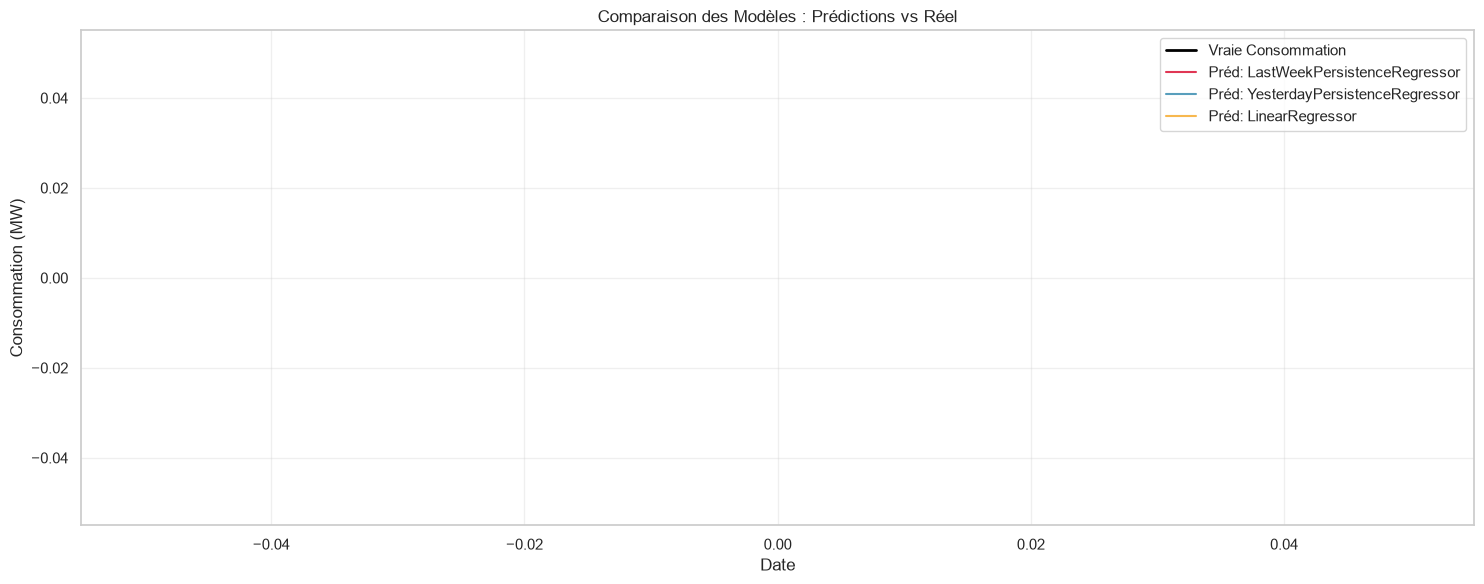

In [9]:
# 5. Graphique des prédictions (Zoom sur le mois de Janvier 2025 pour y voir clair)
start_zoom = pd.to_datetime('2025-01-05').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2025-01-15').tz_localize('Europe/Paris')

evaluator.plot_predictions(df_test, start_date=start_zoom, end_date=end_zoom)


# Rolling Validation (Walk-Forward)
Au lieu de tester sur une seule année, nous entraînons et testons nos modèles de manière glissante d'année en année (ex: Entraînement 2016-2021 -> Test 2022, puis Entraînement 2016-2022 -> Test 2023).

In [10]:
print("--- Lancement de la Validation Walk-Forward ---")
model_lr = LinearRegressor()
# On évalue le modèle Linéaire sur 3 ans (2022, 2023, 2024)
# Entraînement QUOTIDIEN ! (step_size='1D') On simule 365 ré-entraînements sur l'année 2024.
metrics_df = evaluator.rolling_validation(model_lr, start_date='2024-01-01', end_date='2024-12-31', step_size='1D')
display(metrics_df)


--- Lancement de la Validation Walk-Forward ---

========== ROLLING VALIDATION : LinearRegressor ==========
[2022] Train: 52607h | Test: 8760h --> MAE: 2493.88 MW | RMSE: 3270.83 MW
[2023] Train: 61367h | Test: 8760h --> MAE: 2429.96 MW | RMSE: 3123.93 MW
[2024] Train: 70127h | Test: 8784h --> MAE: 2304.32 MW | RMSE: 3015.73 MW
-------------------------------------------------------
SCORE MOYEN ROLLING : MAE = 2409.39 MW | RMSE = 3136.83 MW



,Année,MAE,RMSE
0,2022,2493.883084,3270.831120
1,2023,2429.956430,3123.930551
2,2024,2304.316261,3015.734760


Make sure no data leak
Fill temperature